# Perturbation Performance vs. Number of Perturbed Genes

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../../scripts')

import numpy as np
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import scvi
from scipy.stats import pearsonr, spearmanr

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features
from perturb_utils import load_crc_slide, _get_domain_labels
from configs.cellina_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
from counterfactual_analysis import (
    safe_log2_fold_change, precision_at_k,
    e_distance, subsample_cells, _normalize_counts,
)

plt.rcParams['figure.dpi'] = 100
scvi.settings.seed = 0
print(cellina.__version__)


EDISTANCE_SUBSAMPLE = 500
EDISTANCE_N_ITER = 10


def direction_match(gt_vec, cf_vec, k):
    gt_topk = set(np.argsort(-np.abs(gt_vec))[:k])
    cf_topk = set(np.argsort(-np.abs(cf_vec))[:k])
    intersect = list(gt_topk & cf_topk)
    if len(intersect) == 0:
        return 0.0
    return float(np.mean(np.sign(gt_vec[intersect]) == np.sign(cf_vec[intersect])))


def compute_metrics(ref_expr, pert_expr, obs_expr, top_n=200, eps=1e-8, scale=1e4):
    """Mirrors eval_loo compute_lfc_metrics + get_edistance on raw expression arrays."""
    ref_norm  = _normalize_counts(ref_expr,  eps=eps, scale=scale)
    obs_norm  = _normalize_counts(obs_expr,  eps=eps, scale=scale)
    pert_norm = _normalize_counts(pert_expr, eps=eps, scale=scale)

    mean_ref  = np.nanmean(ref_norm,  axis=0)
    mean_obs  = np.nanmean(obs_norm,  axis=0)
    mean_pert = np.nanmean(pert_norm, axis=0)

    gt_vec = safe_log2_fold_change(mean_obs,  mean_ref, eps=eps)
    cf_vec = safe_log2_fold_change(mean_pert, mean_ref, eps=eps)

    top_features = np.argsort(-np.abs(gt_vec))[:top_n]
    pear,  _ = pearsonr( gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    prec     = precision_at_k(gt_vec, cf_vec, k=top_n, use_abs=True)
    dir_m    = direction_match(gt_vec, cf_vec, k=top_n)

    pop_a = np.log1p(obs_norm[:,  top_features])
    pop_b = np.log1p(pert_norm[:, top_features])
    edists = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE))
        for _ in range(EDISTANCE_N_ITER)
    ]
    edists_local = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE), local=True)
        for _ in range(EDISTANCE_N_ITER)
    ]
    rmse_log1p = float(np.sqrt(np.mean(
        (np.log1p(obs_norm).sum(0) - np.log1p(pert_norm).sum(0)) ** 2
    )))

    return dict(
        pearson_r=float(pear),
        spearman_r=float(spear),
        precision=float(prec),
        direction_match=float(dir_m),
        edistance=float(np.mean(edists)),
        edistance_local=float(np.mean(edists_local)),
        rmse_log1p=rmse_log1p,
    )

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

0.7.1


In [ ]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id             = 120
labels_key           = 'coarse_type'
domains_key          = 'typ'
top_n                = 50                        # metric evaluation window (fixed)
top_n_perturb_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000] # sweep
batch_size           = 512
min_cells            = 50
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_ID'
library_size     = 'latent'

## 1. Data

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

ref_label, crc_labels = _get_domain_labels(adata, domains_key)
print(f'ref={ref_label!r}, crc={crc_labels}')

AnnData object with n_obs × n_vars = 246316 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [4]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)

## 2. Model

In [5]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x'
)

model = CellinaModel(adata, **MODEL_ARGS)


INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [6]:
train_args = {**TRAIN_ARGS, "devices": [1], "batch_size": batch_size, "train_size": 0.9, "validation_size": 0.1}
model.train(**train_args, plan_kwargs=PLAN_KWARGS)

model.save(save_path, overwrite=True)


INFO: GPU available: True (cuda), used: True
2026-04-20 08:59:58 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-04-20 08:59:58 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-04-20 08:59:58 | [INFO] HPU available: False, using: 0 HPUs


INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-04-20 08:59:58 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
2026-04-20 08:59:58 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 468.946. Signaling Trainer to stop.


## 3. Pseudobulk logFC — Global & Cell-type-specific

In [7]:
model = CellinaModel.load(save_path, adata)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-04-20 09:20:35 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File results/perturb_loo/trained/crc_231_ID/model.pt already downloaded                                   


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [8]:
adata.obs[domains_key]

c_3_1_8         231_TVA
c_3_1_12        231_TVA
c_3_1_13        231_TVA
c_3_1_14        231_TVA
c_3_1_16        231_TVA
                 ...   
c_3_146_1282    231_REF
c_3_146_1286    231_REF
c_3_146_1291    231_REF
c_3_146_1292    231_REF
c_3_146_1297    231_REF
Name: typ, Length: 246316, dtype: category
Categories (3, object): ['231_CRC', '231_REF', '231_TVA']

In [9]:
# Global: all cells pooled together
pdata_global = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_global, target_sum=1e4)
sc.pp.log1p(pdata_global)

_crc_X    = pdata_global[pdata_global.obs[domains_key].isin(crc_labels)].X
_ref_X    = pdata_global[pdata_global.obs[domains_key] == ref_label].X
_crc_mean = np.asarray(_crc_X.mean(axis=0)).flatten() if sp.issparse(_crc_X) else _crc_X.mean(axis=0).flatten()
_ref_mean = np.asarray(_ref_X.mean(axis=0)).flatten() if sp.issparse(_ref_X) else _ref_X.mean(axis=0).flatten()
global_logfc_series = pd.Series(_crc_mean - _ref_mean, index=pdata_global.var_names)

# Cell-type-specific
pdata_ct = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_ct, target_sum=1e4)
sc.pp.log1p(pdata_ct)

cell_types_with_both = [
    ct for ct in pdata_ct.obs[labels_key].unique()
    if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
    and (pdata_ct.obs[domains_key].isin(crc_labels) & (pdata_ct.obs[labels_key] == ct)).any()
]

_ct_rows = []
for _ct in cell_types_with_both:
    _crc_ct = pdata_ct[pdata_ct.obs[domains_key].isin(crc_labels) & (pdata_ct.obs[labels_key] == _ct)].X
    _ref_ct = pdata_ct[(pdata_ct.obs[domains_key] == ref_label)   & (pdata_ct.obs[labels_key] == _ct)].X
    _crc_m  = np.asarray(_crc_ct.mean(axis=0)).flatten() if sp.issparse(_crc_ct) else _crc_ct.mean(axis=0).flatten()
    _ref_m  = np.asarray(_ref_ct.mean(axis=0)).flatten() if sp.issparse(_ref_ct) else _ref_ct.mean(axis=0).flatten()
    _ct_rows.append(pd.Series(_crc_m - _ref_m, index=pdata_ct.var_names, name=_ct))
domain_logfc_df = pd.concat(_ct_rows, axis=1).T

print(f"Global logFC: {global_logfc_series.shape[0]} genes")
print(f"CT-specific logFC: {domain_logfc_df.shape} (cell types × genes)")

Global logFC: 3000 genes
CT-specific logFC: (7, 3000) (cell types × genes)


## 4. Pre-compute Fixed Expressions per Cell Type

In [10]:
import scanpy as sc  # needed for sc.pp calls above in case not imported

ref_idxs = {}   # ct → indices in REF
crc_idxs = {}   # ct → indices in CRC
ref_exprs = {}  # ct → (n_ref, n_genes)
cf_exprs  = {}  # ct → (n_crc, n_genes)  real CRC, ground truth
swap_exprs = {} # ct → (n_ref, n_genes)  counterfactual (graph swap)

cell_types = []
for ct in sorted(cell_types_with_both):
    ref_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    )[0]
    crc_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key].isin(crc_labels))
    )[0]
    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue
    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
    ref_idxs[ct]  = ref_idx
    crc_idxs[ct]  = crc_idx
    ref_exprs[ct]  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    cf_exprs[ct]   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)
    swap_exprs[ct] = model.get_counterfactual_expression(ref_idx, crc_idx, batch_size=batch_size, library_size=library_size)
    cell_types.append(ct)

print(f"\nEvaluating {len(cell_types)} cell types: {cell_types}")

  Endothelial: ref=1041, crc=1545
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Epithelial: ref=24934, crc=27904


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  Fibroblast: ref=10734, crc=23051
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Myeloid: ref=2862, crc=2115


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  Smooth_muscle: ref=985, crc=3216
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  T_cell: ref=4177, crc=4313


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        

Evaluating 7 cell types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


## 5. Counterfactual Baseline (Fixed)

In [11]:
_metric_keys = ('pearson_r', 'spearman_r', 'precision', 'direction_match', 'edistance', 'edistance_local', 'rmse_log1p')
cf_metrics_vals = {k: [] for k in _metric_keys}
for ct in cell_types:
    stats = compute_metrics(ref_exprs[ct], swap_exprs[ct], cf_exprs[ct], top_n=top_n)
    for k in _metric_keys:
        cf_metrics_vals[k].append(stats[k])

cf_avg_pearson    = float(np.mean(cf_metrics_vals['pearson_r']))
cf_avg_spearman   = float(np.mean(cf_metrics_vals['spearman_r']))
cf_avg_prec       = float(np.mean(cf_metrics_vals['precision']))
cf_avg_dir_match  = float(np.mean(cf_metrics_vals['direction_match']))
cf_avg_edistance  = float(np.mean(cf_metrics_vals['edistance']))
cf_avg_edist_loc  = float(np.mean(cf_metrics_vals['edistance_local']))
cf_avg_rmse_log1p = float(np.mean(cf_metrics_vals['rmse_log1p']))
print(f"Counterfactual avg Pearson r       = {cf_avg_pearson:.3f}")
print(f"Counterfactual avg Spearman r      = {cf_avg_spearman:.3f}")
print(f"Counterfactual avg precision@{top_n:<4} = {cf_avg_prec:.3f}")
print(f"Counterfactual avg direction_match = {cf_avg_dir_match:.3f}")
print(f"Counterfactual avg edistance       = {cf_avg_edistance:.4f}")
print(f"Counterfactual avg edist_local     = {cf_avg_edist_loc:.4f}")
print(f"Counterfactual avg RMSE log1p      = {cf_avg_rmse_log1p:.4f}")

cf_ct_spearman = {ct: cf_metrics_vals['spearman_r'][i] for i, ct in enumerate(cell_types)}
cf_ct_precision = {ct: cf_metrics_vals['precision'][i] for i, ct in enumerate(cell_types)}


Counterfactual avg Pearson r       = 0.891
Counterfactual avg Spearman r      = 0.829
Counterfactual avg precision@50   = 0.671
Counterfactual avg direction_match = 1.000
Counterfactual avg edistance       = 0.2645
Counterfactual avg edist_local     = 0.1889
Counterfactual avg RMSE log1p      = 4834.0810


## 6. Sweep: Global vs Cell-type-specific

In [12]:
global_results        = []
ctspec_results        = []
global_edist_results  = []
ctspec_edist_results  = []
global_spear_results  = []
ctspec_spear_results  = []
global_prec_results   = []
ctspec_prec_results   = []
global_dirmatch_results  = []
ctspec_dirmatch_results  = []
global_edist_loc_results = []
ctspec_edist_loc_results = []
global_rmse_results   = []
ctspec_rmse_results   = []

global_ct_spear_records = []
ctspec_ct_spear_records = []
global_ct_prec_records  = []
ctspec_ct_prec_records  = []

for n in top_n_perturb_values:
    print(f"\n── top_n_perturb = {n} ──")

    # ── Global perturbation ──────────────────────────────────────────────────
    top_genes = global_logfc_series.abs().nlargest(n).index.tolist()
    logfc_dict = {g: float(global_logfc_series[g]) for g in top_genes}
    make_neighbor_perturbation(adata, perturbations=logfc_dict, obsm_key_out='spatial_x_cf', base=np.e)

    g_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        for k in _metric_keys:
            g_vals[k].append(stats[k])

    avg_g        = float(np.mean(g_vals['pearson_r']))
    avg_g_spear  = float(np.mean(g_vals['spearman_r']))
    avg_g_prec   = float(np.mean(g_vals['precision']))
    avg_g_dir    = float(np.mean(g_vals['direction_match']))
    avg_g_edist  = float(np.mean(g_vals['edistance']))
    avg_g_eloc   = float(np.mean(g_vals['edistance_local']))
    avg_g_rmse   = float(np.mean(g_vals['rmse_log1p']))
    global_results.append(avg_g)
    global_spear_results.append(avg_g_spear)
    global_prec_results.append(avg_g_prec)
    global_dirmatch_results.append(avg_g_dir)
    global_edist_results.append(avg_g_edist)
    global_edist_loc_results.append(avg_g_eloc)
    global_rmse_results.append(avg_g_rmse)
    global_ct_spear_records.append(dict(zip(cell_types, g_vals['spearman_r'])))
    global_ct_prec_records.append(dict(zip(cell_types, g_vals['precision'])))
    print(f"  global:      Pearson r = {avg_g:.3f}  Spearman r = {avg_g_spear:.3f}  prec = {avg_g_prec:.3f}  dir = {avg_g_dir:.3f}  edist = {avg_g_edist:.4f}  edist_loc = {avg_g_eloc:.4f}  rmse_log1p = {avg_g_rmse:.4f}")

    # ── Cell-type-specific perturbation ──────────────────────────────────────
    logfc_series_dict = {}
    for ct in domain_logfc_df.index:
        s = domain_logfc_df.loc[ct]
        top_g = s.abs().nlargest(n).index.tolist()
        logfc_series_dict[ct] = s[top_g]
    make_neighbor_perturbation(
        adata, perturbations=logfc_series_dict, groupby=labels_key,
        obsm_key_out='spatial_x_cf', base=np.e,
    )

    c_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        for k in _metric_keys:
            c_vals[k].append(stats[k])

    avg_c        = float(np.mean(c_vals['pearson_r']))
    avg_c_spear  = float(np.mean(c_vals['spearman_r']))
    avg_c_prec   = float(np.mean(c_vals['precision']))
    avg_c_dir    = float(np.mean(c_vals['direction_match']))
    avg_c_edist  = float(np.mean(c_vals['edistance']))
    avg_c_eloc   = float(np.mean(c_vals['edistance_local']))
    avg_c_rmse   = float(np.mean(c_vals['rmse_log1p']))
    ctspec_results.append(avg_c)
    ctspec_spear_results.append(avg_c_spear)
    ctspec_prec_results.append(avg_c_prec)
    ctspec_dirmatch_results.append(avg_c_dir)
    ctspec_edist_results.append(avg_c_edist)
    ctspec_edist_loc_results.append(avg_c_eloc)
    ctspec_rmse_results.append(avg_c_rmse)
    ctspec_ct_spear_records.append(dict(zip(cell_types, c_vals['spearman_r'])))
    ctspec_ct_prec_records.append(dict(zip(cell_types, c_vals['precision'])))
    print(f"  CT-specific: Pearson r = {avg_c:.3f}  Spearman r = {avg_c_spear:.3f}  prec = {avg_c_prec:.3f}  dir = {avg_c_dir:.3f}  edist = {avg_c_edist:.4f}  edist_loc = {avg_c_eloc:.4f}  rmse_log1p = {avg_c_rmse:.4f}")

# clean up temporary obsm key
if 'spatial_x_cf' in adata.obsm:
    del adata.obsm['spatial_x_cf']

global_ct_spearman_df = pd.DataFrame(global_ct_spear_records, index=top_n_perturb_values).T
ctspec_ct_spearman_df = pd.DataFrame(ctspec_ct_spear_records, index=top_n_perturb_values).T
global_ct_precision_df = pd.DataFrame(global_ct_prec_records, index=top_n_perturb_values).T
ctspec_ct_precision_df = pd.DataFrame(ctspec_ct_prec_records, index=top_n_perturb_values).T



── top_n_perturb = 10 ──
  global:      Pearson r = 0.795  Spearman r = 0.736  prec = 0.469  dir = 0.968  edist = 1.4857  edist_loc = 0.9938  rmse_log1p = 5298.2369
  CT-specific: Pearson r = 0.717  Spearman r = 0.691  prec = 0.449  dir = 0.959  edist = 1.4848  edist_loc = 1.0041  rmse_log1p = 5287.9404

── top_n_perturb = 20 ──
  global:      Pearson r = 0.818  Spearman r = 0.758  prec = 0.509  dir = 1.000  edist = 1.2729  edist_loc = 0.8602  rmse_log1p = 5247.1048
  CT-specific: Pearson r = 0.752  Spearman r = 0.730  prec = 0.451  dir = 0.986  edist = 1.3589  edist_loc = 0.9438  rmse_log1p = 5258.1099

── top_n_perturb = 50 ──
  global:      Pearson r = 0.797  Spearman r = 0.756  prec = 0.500  dir = 1.000  edist = 0.9342  edist_loc = 0.6825  rmse_log1p = 5166.7795
  CT-specific: Pearson r = 0.791  Spearman r = 0.755  prec = 0.506  dir = 1.000  edist = 1.1406  edist_loc = 0.8063  rmse_log1p = 5199.6955

── top_n_perturb = 100 ──
  global:      Pearson r = 0.782  Spearman r = 0.744  p

In [13]:
import os

results_dir = f'{base_path}/gene_range'
os.makedirs(results_dir, exist_ok=True)

sweep_df = pd.DataFrame({
    'top_n_perturb':          top_n_perturb_values,
    'global_pearson_r':       global_results,
    'ctspec_pearson_r':       ctspec_results,
    'global_spearman_r':      global_spear_results,
    'ctspec_spearman_r':      ctspec_spear_results,
    'global_precision':       global_prec_results,
    'ctspec_precision':       ctspec_prec_results,
    'global_direction_match': global_dirmatch_results,
    'ctspec_direction_match': ctspec_dirmatch_results,
    'global_edistance':       global_edist_results,
    'ctspec_edistance':       ctspec_edist_results,
    'global_edistance_local': global_edist_loc_results,
    'ctspec_edistance_local': ctspec_edist_loc_results,
    'global_rmse_log1p':      global_rmse_results,
    'ctspec_rmse_log1p':      ctspec_rmse_results,
})
sweep_df.to_csv(f'{results_dir}/sweep_results.csv', index=False)

baseline_df = pd.DataFrame([{
    'pearson_r':       cf_avg_pearson,
    'spearman_r':      cf_avg_spearman,
    'precision':       cf_avg_prec,
    'direction_match': cf_avg_dir_match,
    'edistance':       cf_avg_edistance,
    'edistance_local': cf_avg_edist_loc,
    'rmse_log1p':      cf_avg_rmse_log1p,
}])
baseline_df.to_csv(f'{results_dir}/baseline_metrics.csv', index=False)

global_ct_spearman_df.to_csv(f'{results_dir}/global_ct_spearman.csv')
ctspec_ct_spearman_df.to_csv(f'{results_dir}/ctspec_ct_spearman.csv')
global_ct_precision_df.to_csv(f'{results_dir}/global_ct_precision.csv')
ctspec_ct_precision_df.to_csv(f'{results_dir}/ctspec_ct_precision.csv')
pd.Series(cf_ct_spearman, name='spearman_r').to_csv(f'{results_dir}/cf_ct_spearman.csv')
pd.Series(cf_ct_precision, name='precision').to_csv(f'{results_dir}/cf_ct_precision.csv')

print(f"Saved to {results_dir}/")


Saved to results/perturb_loo/gene_range/


In [14]:
# ── Load results (run this cell to skip the sweep and go straight to plotting) ──
results_dir = f'{base_path}/gene_range'
sweep_df    = pd.read_csv(f'{results_dir}/sweep_results.csv')
baseline_df = pd.read_csv(f'{results_dir}/baseline_metrics.csv')

top_n_perturb_values      = sweep_df['top_n_perturb'].tolist()
global_results            = sweep_df['global_pearson_r'].tolist()
ctspec_results            = sweep_df['ctspec_pearson_r'].tolist()
global_spear_results      = sweep_df['global_spearman_r'].tolist()
ctspec_spear_results      = sweep_df['ctspec_spearman_r'].tolist()
global_prec_results       = sweep_df['global_precision'].tolist()
ctspec_prec_results       = sweep_df['ctspec_precision'].tolist()
global_dirmatch_results   = sweep_df['global_direction_match'].tolist()
ctspec_dirmatch_results   = sweep_df['ctspec_direction_match'].tolist()
global_edist_results      = sweep_df['global_edistance'].tolist()
ctspec_edist_results      = sweep_df['ctspec_edistance'].tolist()
global_edist_loc_results  = sweep_df['global_edistance_local'].tolist()
ctspec_edist_loc_results  = sweep_df['ctspec_edistance_local'].tolist()
global_rmse_results       = sweep_df['global_rmse_log1p'].tolist()
ctspec_rmse_results       = sweep_df['ctspec_rmse_log1p'].tolist()

cf_avg_pearson    = float(baseline_df['pearson_r'].iloc[0])
cf_avg_spearman   = float(baseline_df['spearman_r'].iloc[0])
cf_avg_prec       = float(baseline_df['precision'].iloc[0])
cf_avg_dir_match  = float(baseline_df['direction_match'].iloc[0])
cf_avg_edistance  = float(baseline_df['edistance'].iloc[0])
cf_avg_edist_loc  = float(baseline_df['edistance_local'].iloc[0])
cf_avg_rmse_log1p = float(baseline_df['rmse_log1p'].iloc[0])

try:
    global_ct_spearman_df  = pd.read_csv(f'{results_dir}/global_ct_spearman.csv',  index_col=0)
    ctspec_ct_spearman_df  = pd.read_csv(f'{results_dir}/ctspec_ct_spearman.csv',  index_col=0)
    global_ct_precision_df = pd.read_csv(f'{results_dir}/global_ct_precision.csv', index_col=0)
    ctspec_ct_precision_df = pd.read_csv(f'{results_dir}/ctspec_ct_precision.csv', index_col=0)
    global_ct_spearman_df.columns  = global_ct_spearman_df.columns.astype(int)
    ctspec_ct_spearman_df.columns  = ctspec_ct_spearman_df.columns.astype(int)
    global_ct_precision_df.columns = global_ct_precision_df.columns.astype(int)
    ctspec_ct_precision_df.columns = ctspec_ct_precision_df.columns.astype(int)
    cf_ct_spearman  = pd.read_csv(f'{results_dir}/cf_ct_spearman.csv',  index_col=0)['spearman_r']
    cf_ct_precision = pd.read_csv(f'{results_dir}/cf_ct_precision.csv', index_col=0)['precision']
    print("Per-cell-type data loaded.")
except FileNotFoundError:
    print("Per-cell-type CSVs not found — re-run cells 17 and 18 to generate them.")

print(f"Loaded from {results_dir}/")


Per-cell-type data loaded.
Loaded from results/perturb_loo/gene_range/


## 7. Summary Plot

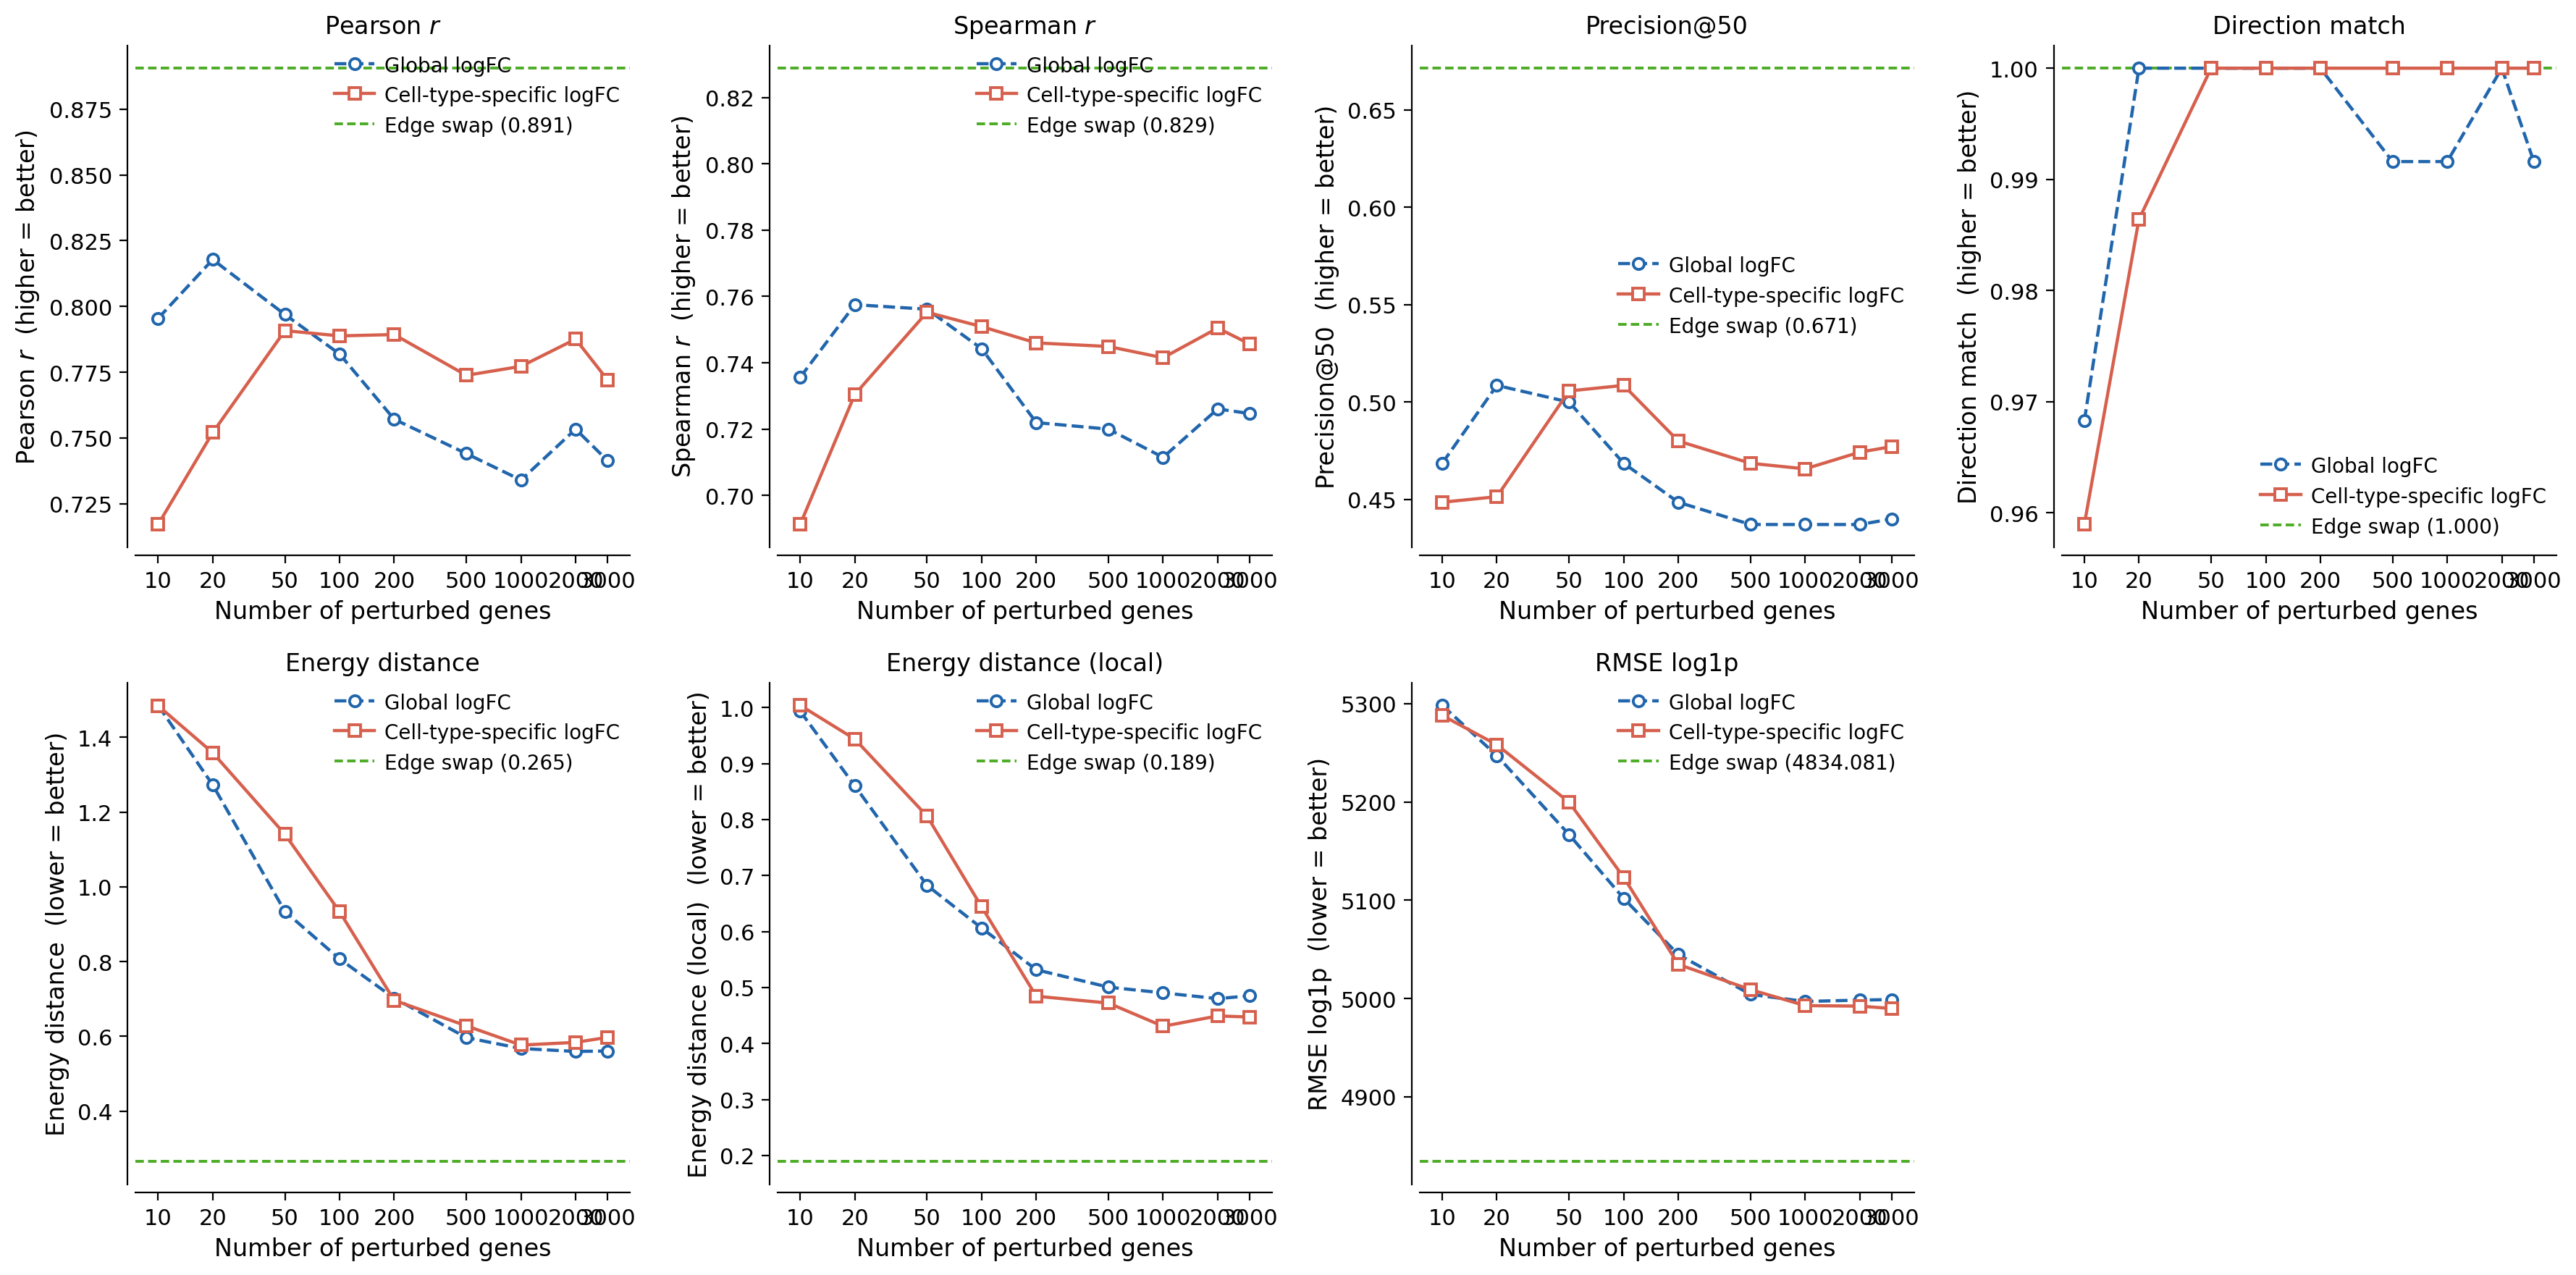

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 13,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 13,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

metrics = [
    ('pearson_r',       global_results,           ctspec_results,           cf_avg_pearson,    'Pearson $r$',           True),
    ('spearman_r',      global_spear_results,      ctspec_spear_results,     cf_avg_spearman,   'Spearman $r$',          True),
    ('precision',       global_prec_results,       ctspec_prec_results,      cf_avg_prec,       f'Precision@{top_n}',    True),
    ('direction_match', global_dirmatch_results,   ctspec_dirmatch_results,  cf_avg_dir_match,  'Direction match',       True),
    ('edistance',       global_edist_results,      ctspec_edist_results,     cf_avg_edistance,  'Energy distance',       False),
    ('edistance_local', global_edist_loc_results,  ctspec_edist_loc_results, cf_avg_edist_loc,  'Energy distance (local)', False),
    ('rmse_log1p',      global_rmse_results,       ctspec_rmse_results,      cf_avg_rmse_log1p, 'RMSE log1p',            False),
]

ncols = 4
nrows = -(-len(metrics) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
axes = axes.flatten()

for i, (key, g_vals, c_vals, cf_val, ylabel, higher_better) in enumerate(metrics):
    ax = axes[i]
    direction = 'higher = better' if higher_better else 'lower = better'

    ax.plot(
        top_n_perturb_values, g_vals,
        color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
        markerfacecolor='white', markeredgewidth=1.4,
        label='Global logFC', zorder=3,
    )
    ax.plot(
        top_n_perturb_values, c_vals,
        color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
        markerfacecolor='white', markeredgewidth=1.4,
        label='Cell-type-specific logFC', zorder=3,
    )
    ax.axhline(
        cf_val, color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
        label=f'Edge swap ({cf_val:.3f})', zorder=2,
    )
    ax.set_xscale('log')
    ax.set_xticks(top_n_perturb_values)
    ax.set_xticklabels([str(v) for v in top_n_perturb_values], rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes', fontsize=12)
    ax.set_ylabel(f'{ylabel}  ({direction})')
    ax.set_title(ylabel)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=10)

for j in range(len(metrics), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()


## 8. Per-cell-type Heatmaps (Spearman r & Precision)

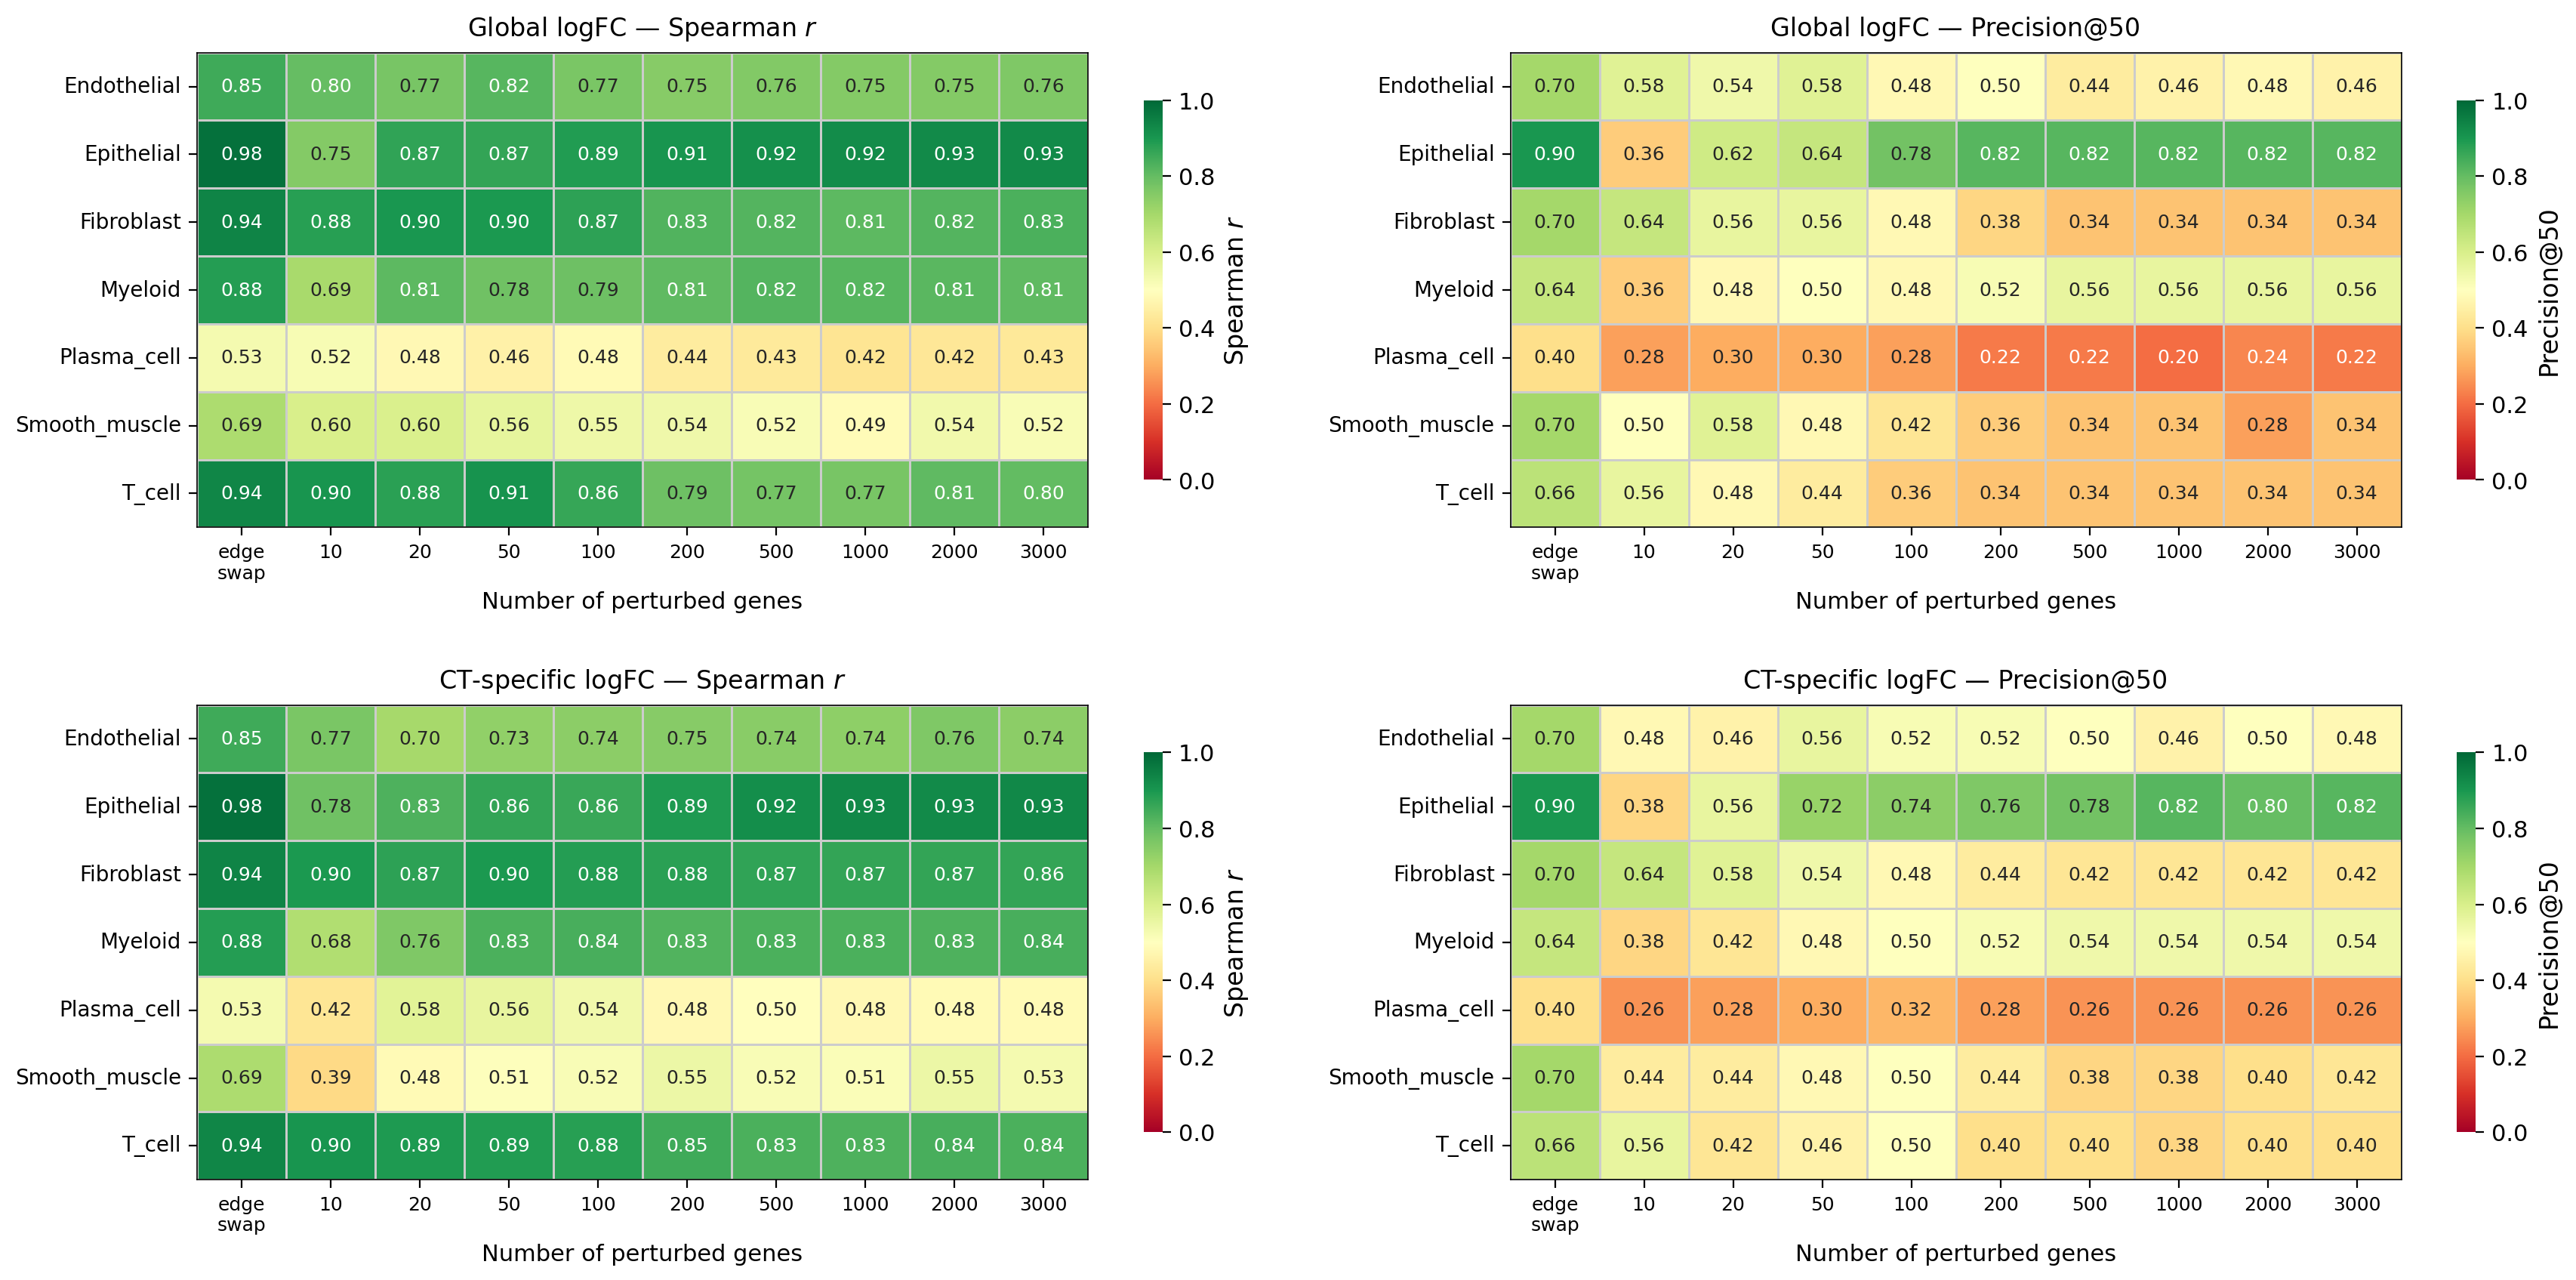

In [16]:
import seaborn as sns

x_labels = ['edge\nswap'] + [str(n) for n in top_n_perturb_values]

heatmap_specs = [
    (global_ct_spearman_df,  cf_ct_spearman,  'Global logFC — Spearman $r$',          'spearman_r'),
    (global_ct_precision_df, cf_ct_precision, f'Global logFC — Precision@{top_n}',     'precision'),
    (ctspec_ct_spearman_df,  cf_ct_spearman,  'CT-specific logFC — Spearman $r$',      'spearman_r'),
    (ctspec_ct_precision_df, cf_ct_precision, f'CT-specific logFC — Precision@{top_n}', 'precision'),
]

vmin_spear, vmax_spear = 0.0, 1.0
vmin_prec,  vmax_prec  = 0.0, 1.0

fig, axes = plt.subplots(2, 2, figsize=(18, 9))

for ax, (df, cf_series, title, metric) in zip(axes.flatten(), heatmap_specs):
    cf_col = cf_series.reindex(df.index)
    data = pd.concat([cf_col.rename('edge\nswap'), df], axis=1)
    data.columns = x_labels

    vmin = vmin_spear if metric == 'spearman_r' else vmin_prec
    vmax = vmax_spear if metric == 'spearman_r' else vmax_prec

    sns.heatmap(
        data,
        ax=ax,
        vmin=vmin, vmax=vmax,
        cmap='RdYlGn',
        annot=True, fmt='.2f',
        annot_kws={'size': 9},
        linewidths=0.4, linecolor='#cccccc',
        cbar_kws={'shrink': 0.8, 'label': title.split('—')[1].strip()},
    )
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel('Number of perturbed genes', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9, rotation=0)
    ax.tick_params(axis='y', labelsize=10, rotation=0)

    # highlight edge-swap column with a thicker border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.6)

fig.tight_layout(pad=2.0)
plt.show()
